In [50]:
import json
import os
import pandas as pd
import glob
from pathlib import Path
import numpy as np

In [51]:
# ── Change this to select the dataset ──────────────────────────────────────
DATASET = 'big_rw'   # whatever datasets are present under Cox/Results
# ───────────────────────────────────────────────────────────────────────────

In [52]:
def collect_results(base_path="../Cox/Results"):
    """
    Collect Cox results. Test and val metrics live in separate JSON files:
      .../seed_N/results_test.json  -> {'ci': ..., 'bs': ...}
      .../seed_N/results_val.json   -> {'ci': ..., 'bs': ...}
    Path encodes: agent / dataset / arch / lambda_L / landmark_B / target_lr_T / exp_1 / seed_N
    """
    datasets = ['nasa', 'mimic', 'big_rw', 'churn_lastfm_months']
    results = []

    test_files = glob.glob(os.path.join(base_path, "**/results_test.json"), recursive=True)
    print(f"Found {len(test_files)} test result files")

    for test_file in test_files:
        val_file = test_file.replace('results_test.json', 'results_val.json')
        if not os.path.exists(val_file):
            print(f"Missing val file for {test_file}, skipping")
            continue
        try:
            with open(test_file) as f:
                test_data = json.load(f)
            with open(val_file) as f:
                val_data = json.load(f)

            parts = Path(test_file).parts

            agent = dataset = lambda_val = target_lr_val = landmark_val = seed = None
            for part in parts:
                if part in ('DeepLambdaSA', 'SA', 'LambdaSA'):
                    agent = part
                elif part in datasets:
                    dataset = part
                elif part.startswith('lambda_'):
                    lambda_val = float(part.replace('lambda_', ''))
                elif part.startswith('target_lr_'):
                    target_lr_val = float(part.replace('target_lr_', ''))
                elif part == 'landmark_True':
                    landmark_val = True
                elif part == 'landmark_False':
                    landmark_val = False
                elif part.startswith('seed_'):
                    seed = int(part.replace('seed_', ''))

            if agent is None or dataset is None or seed is None:
                continue

            results.append({
                'algorithm': agent,
                'dataset':   dataset,
                'seed':      seed,
                'lambda_':   lambda_val,
                'target_lr': target_lr_val,
                'landmark':  landmark_val,
                'test_ci':   test_data['ci'],
                'test_bs':   test_data['bs'],
                'val_ci':    val_data['ci'],
                'val_bs':    val_data['bs'],
            })
        except Exception as e:
            print(f"Error processing {test_file}: {e}")

    print(f"Successfully collected {len(results)} experiments")
    return results

In [53]:
results = collect_results()
df = pd.DataFrame(results)
print(f"Total experiments: {len(df)}")

if len(df) > 0:
    print(f"Datasets:   {df['dataset'].unique()}")
    print(f"Algorithms: {df['algorithm'].unique()}")
    print(f"Seeds:      {sorted(df['seed'].unique())}")
    print("\n=== Distribution ===")
    print(df.groupby(['dataset', 'algorithm']).size().to_frame('count'))
    if 'lambda_' in df.columns:
        print(f"\nLambda values:    {sorted(x for x in df['lambda_'].unique() if pd.notna(x))}")
    if 'target_lr' in df.columns:
        print(f"Target LR values: {sorted(x for x in df['target_lr'].unique() if pd.notna(x))}")
else:
    print("No results found!")

Found 159 test result files
Successfully collected 159 experiments
Total experiments: 159
Datasets:   ['churn_lastfm_months' 'big_rw']
Algorithms: ['DeepLambdaSA' 'SA']
Seeds:      [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

=== Distribution ===
                                  count
dataset             algorithm          
big_rw              DeepLambdaSA    132
                    SA               22
churn_lastfm_months DeepLambdaSA      5

Lambda values:    [0.1, 0.5, 0.8, 0.9, 0.95]
Target LR values: [0.05, 0.1, 0.25]


In [54]:
def analyze_dataset_summary(df, dataset):
    dset_df = df[df['dataset'] == dataset]
    print(f"{dataset} Summary:")
    print(f"Total experiments: {len(dset_df)}")
    print(f"Algorithms: {dset_df['algorithm'].unique()}")
    print(f"Seeds: {sorted(dset_df['seed'].unique())}")
    if 'lambda_' in dset_df.columns:
        print(f"Lambda values: {sorted(x for x in dset_df['lambda_'].unique() if pd.notna(x))}")
    if 'target_lr' in dset_df.columns:
        print(f"Target LR (τ) values: {sorted(x for x in dset_df['target_lr'].unique() if pd.notna(x))}")

analyze_dataset_summary(df, DATASET)

big_rw Summary:
Total experiments: 154
Algorithms: ['DeepLambdaSA' 'SA']
Seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Lambda values: [0.1, 0.5, 0.8, 0.9, 0.95]
Target LR (τ) values: [0.05, 0.1, 0.25]


In [55]:
df

,algorithm,dataset,seed,lambda_,target_lr,landmark,test_ci,test_bs,val_ci,val_bs
0,DeepLambdaSA,churn_lastfm_months,0,0.5,0.05,True,0.781783,0.193523,0.774009,0.174641
1,DeepLambdaSA,churn_lastfm_months,0,0.5,0.10,True,0.779413,0.132766,0.770331,0.126293
2,DeepLambdaSA,churn_lastfm_months,0,0.1,0.05,True,0.615367,0.280531,0.608945,0.252224
3,DeepLambdaSA,churn_lastfm_months,0,0.1,0.10,True,0.675588,0.195054,0.641202,0.173852
4,DeepLambdaSA,churn_lastfm_months,0,0.1,0.25,True,0.616957,0.191714,0.607617,0.186298
...,...,...,...,...,...,...,...,...,...,...
154,SA,big_rw,1,0.9,0.10,True,0.705521,0.136487,0.637854,0.155260
155,SA,big_rw,8,0.9,0.10,True,0.776244,0.113281,0.758656,0.116529
156,SA,big_rw,9,0.9,0.10,True,0.595760,0.178701,0.631516,0.162418
157,SA,big_rw,0,0.9,0.10,True,0.737903,0.127808,0.721839,0.131274


In [56]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rcParams['figure.figsize'] = (15, 8)

In [57]:
def plot_test_validation_comparison(df, dataset):
    """Plot test/val metrics for any dataset. Cox-TC (DeepLambdaSA) vs Cox (SA) baseline."""

    dset_df = df[df['dataset'] == dataset]
    tc_data = dset_df[dset_df['algorithm'] == 'DeepLambdaSA']
    sa_lm   = dset_df[(dset_df['algorithm'] == 'SA') & (dset_df['landmark'] == True)]
    sa_no   = dset_df[(dset_df['algorithm'] == 'SA') & (dset_df['landmark'] == False)]

    if len(dset_df) == 0:
        print(f"No data available for dataset '{dataset}'")
        return

    tc_grouped = None
    if len(tc_data) > 0:
        tc_grouped = tc_data.groupby(['lambda_', 'target_lr']).agg({
            'test_ci': ['mean', 'std', 'count'],
            'test_bs': ['mean', 'std', 'count'],
            'val_ci':  ['mean', 'std'],
            'val_bs':  ['mean', 'std'],
        }).round(4)
        tc_grouped.columns = ['_'.join(col).strip() for col in tc_grouped.columns]
        tc_grouped = tc_grouped.reset_index()
        best_val_ci_idx = tc_grouped['val_ci_mean'].idxmax()
        best_val_bs_idx = tc_grouped['val_bs_mean'].idxmin()
        best_ci_config  = tc_grouped.loc[best_val_ci_idx]
        best_bs_config  = tc_grouped.loc[best_val_bs_idx]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{dataset} — Test vs Validation Performance', fontsize=16, fontweight='bold')

    legend_elements = []

    # SA baseline styles: clearly distinct colors + different linestyles
    sa_styles = [
        (sa_lm, '#E63946', '-.',  'Cox (landmark)'),
        (sa_no, '#F4A261', '--',  'Cox (no-lm)'),
    ]

    for ax, test_col, val_col, ylabel, title in [
        (ax1, 'test_ci', 'val_ci', 'C-Index',     'C-Index: Test (•) vs Validation (■)'),
        (ax2, 'test_bs', 'val_bs', 'Brier Score', 'Brier Score: Test (•) vs Validation (■) — Lower is Better'),
    ]:
        ax.set_title(title, fontsize=14, fontweight='bold')

        for sa_df, color, ls, label in sa_styles:
            if len(sa_df) == 0:
                continue
            test_mean = sa_df[test_col].mean()
            val_mean  = sa_df[val_col].mean()
            ax.axhline(test_mean, color=color, linewidth=2,   linestyle=ls,  alpha=0.9)
            ax.axhline(val_mean,  color=color, linewidth=1.5, linestyle=':',  alpha=0.5)
            if ax is ax1:
                legend_elements.append(plt.Line2D([0], [0], color=color, linewidth=2,
                                                  linestyle=ls, label=label))

        if tc_grouped is not None and len(tc_grouped) > 0:
            target_lrs    = sorted(tc_grouped['target_lr'].unique())
            lambda_values = sorted(tc_grouped['lambda_'].unique())
            colors        = plt.cm.viridis(np.linspace(0, 1, len(target_lrs)))
            lambda_pos    = np.arange(1, len(lambda_values) + 1)
            tau_offsets   = np.linspace(-0.15, 0.15, len(target_lrs))

            t_mean = f'{test_col}_mean'
            t_std  = f'{test_col}_std'
            t_cnt  = f'{test_col}_count'
            v_mean = f'{val_col}_mean'
            v_std  = f'{val_col}_std'

            for i, tau in enumerate(target_lrs):
                subset = tc_grouped[tc_grouped['target_lr'] == tau]
                x_vals, y_test, y_val, e_test, e_val = [], [], [], [], []
                for _, row in subset.iterrows():
                    li = lambda_values.index(row['lambda_'])
                    x_vals.append(lambda_pos[li] + tau_offsets[i])
                    y_test.append(row[t_mean]); e_test.append(row[t_std] / np.sqrt(row[t_cnt]))
                    y_val.append(row[v_mean]);  e_val.append(row[v_std]  / np.sqrt(row[t_cnt]))
                ax.errorbar(x_vals, y_test, yerr=e_test, marker='o', markersize=12, color=colors[i],
                            linewidth=2, capsize=3, alpha=0.9, linestyle='none')
                ax.errorbar(x_vals, y_val,  yerr=e_val,  marker='s', markersize=12, color=colors[i],
                            linewidth=2, capsize=3, alpha=0.5, linestyle='none')
                if ax is ax1:
                    legend_elements.append(plt.Line2D([0], [0], marker='o', color=colors[i],
                                                      linestyle='None', markersize=10, label=f'Cox-TC τ={tau}'))

            ax.set_xticks(lambda_pos)
            ax.set_xticklabels([f'λ={l}' for l in lambda_values])
            ax.set_xlim(0.5, len(lambda_values) + 0.8)

            best_cfg = best_ci_config if 'ci' in test_col else best_bs_config
            li = lambda_values.index(best_cfg['lambda_'])
            ti = target_lrs.index(best_cfg['target_lr'])
            ax.scatter([lambda_pos[li] + tau_offsets[ti]], [best_cfg[t_mean]],
                       s=500, marker='*', color='gold', edgecolor='black', linewidth=3, zorder=10)

        ax.set_xlabel('Lambda (Cox-TC)', fontsize=12, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)

    legend_elements.append(plt.Line2D([0], [0], marker='*', color='gold', linestyle='None',
                                      markersize=16, markeredgecolor='black', label='Best Val→Test'))
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05),
               ncol=len(legend_elements), frameon=False, fontsize=11)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

    if tc_grouped is not None and len(tc_grouped) > 0:
        print(f"Best Val CI: λ={best_ci_config['lambda_']}, τ={best_ci_config['target_lr']} → Test CI: {best_ci_config['test_ci_mean']:.4f}")
        print(f"Best Val BS: λ={best_bs_config['lambda_']}, τ={best_bs_config['target_lr']} → Test BS: {best_bs_config['test_bs_mean']:.4f}")


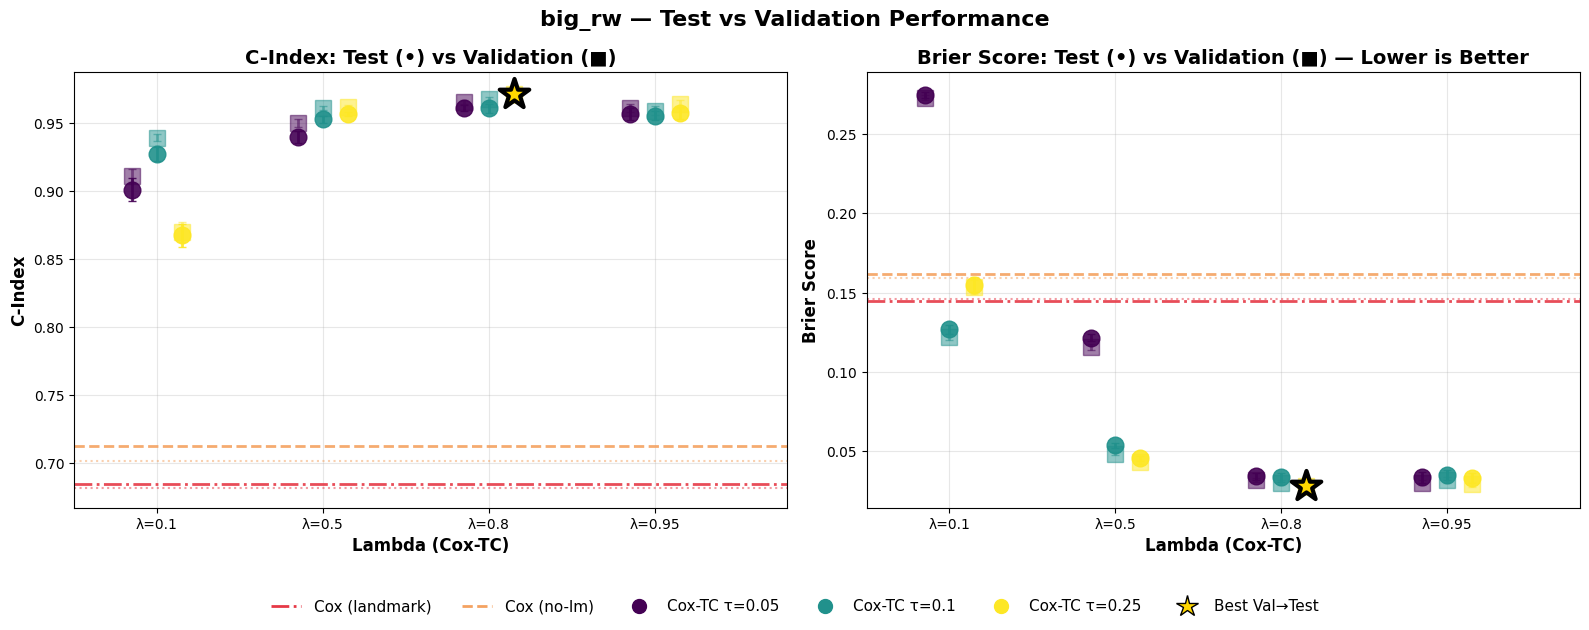

Best Val CI: λ=0.8, τ=0.25 → Test CI: 0.9711
Best Val BS: λ=0.8, τ=0.25 → Test BS: 0.0283


In [58]:
plot_test_validation_comparison(df, DATASET)

In [59]:
def create_performance_table(df, dataset):
    """Performance table with best-val configs highlighted."""

    dset_df = df[df['dataset'] == dataset]
    print("=" * 130)
    print(f"{dataset.upper()} — PERFORMANCE TABLE (Cox)")
    print("=" * 130)

    for landmark, label in [(True, 'SA landmark'), (False, 'SA no-landmark')]:
        sa = dset_df[(dset_df['algorithm'] == 'SA') & (dset_df['landmark'] == landmark)]
        if len(sa) == 0:
            continue
        print(f"\n{label.upper():<20} {'Test CI':<17} {'Val CI':<17} {'Test BS':<17} {'Val BS':<17} {'Seeds':<6}")
        print("-" * 100)
        std_tci = sa['test_ci'].std() if len(sa) > 1 else 0
        std_vci = sa['val_ci'].std()  if len(sa) > 1 else 0
        std_tbs = sa['test_bs'].std() if len(sa) > 1 else 0
        std_vbs = sa['val_bs'].std()  if len(sa) > 1 else 0
        print(f"{'Average ± Std':<20} "
              f"{sa['test_ci'].mean():.4f}±{std_tci:.4f}  "
              f"{sa['val_ci'].mean():.4f}±{std_vci:.4f}  "
              f"{sa['test_bs'].mean():.4f}±{std_tbs:.4f}  "
              f"{sa['val_bs'].mean():.4f}±{std_vbs:.4f}  "
              f"{len(sa)}")

    tc_data = dset_df[dset_df['algorithm'] == 'DeepLambdaSA']
    if len(tc_data) > 0:
        tc_grouped = tc_data.groupby(['lambda_', 'target_lr']).agg({
            'test_ci': ['mean', 'std', 'count'],
            'test_bs': ['mean', 'std'],
            'val_ci':  ['mean', 'std'],
            'val_bs':  ['mean', 'std'],
        }).round(4)
        tc_grouped.columns = ['_'.join(col).strip() for col in tc_grouped.columns]
        tc_grouped = tc_grouped.reset_index()

        best_val_ci_idx = tc_grouped['val_ci_mean'].idxmax()
        best_val_bs_idx = tc_grouped['val_bs_mean'].idxmin()

        print(f"\n{'DeepLambdaSA':<20} {'Test CI':<17} {'Val CI':<17} {'Test BS':<17} {'Val BS':<17} {'N':<4}")
        print("-" * 110)
        for idx, row in tc_grouped.iterrows():
            marker = ""
            if idx == best_val_ci_idx: marker += " ★CI"
            if idx == best_val_bs_idx: marker += " ★BS"
            print(f"λ={row['lambda_']}, τ={row['target_lr']:<6} "
                  f"{row['test_ci_mean']:.4f}±{row['test_ci_std']:.4f}  "
                  f"{row['val_ci_mean']:.4f}±{row['val_ci_std']:.4f}  "
                  f"{row['test_bs_mean']:.4f}±{row['test_bs_std']:.4f}  "
                  f"{row['val_bs_mean']:.4f}±{row['val_bs_std']:.4f}  "
                  f"{int(row['test_ci_count'])}{marker}")

        bc = tc_grouped.loc[best_val_ci_idx]
        bb = tc_grouped.loc[best_val_bs_idx]
        print(f"\n★CI best: λ={bc['lambda_']}, τ={bc['target_lr']} → Val CI={bc['val_ci_mean']:.4f} → Test CI={bc['test_ci_mean']:.4f}")
        print(f"★BS best: λ={bb['lambda_']}, τ={bb['target_lr']} → Val BS={bb['val_bs_mean']:.4f} → Test BS={bb['test_bs_mean']:.4f}")

create_performance_table(df, DATASET)

BIG_RW — PERFORMANCE TABLE (Cox)

SA LANDMARK          Test CI           Val CI            Test BS           Val BS            Seeds 
----------------------------------------------------------------------------------------------------
Average ± Std        0.6841±0.0607  0.6815±0.0555  0.1451±0.0207  0.1460±0.0173  11

SA NO-LANDMARK       Test CI           Val CI            Test BS           Val BS            Seeds 
----------------------------------------------------------------------------------------------------
Average ± Std        0.7121±0.0229  0.7016±0.0177  0.1616±0.0093  0.1593±0.0080  11

DeepLambdaSA         Test CI           Val CI            Test BS           Val BS            N   
--------------------------------------------------------------------------------------------------------------
λ=0.1, τ=0.05   0.9011±0.0272  0.9113±0.0165  0.2747±0.0065  0.2729±0.0047  11
λ=0.1, τ=0.1    0.9272±0.0164  0.9392±0.0086  0.1269±0.0095  0.1220±0.0067  11
λ=0.1, τ=0.25   0.8673±0.02

In [60]:
from scipy.stats import ttest_rel

def paired_ttest(df, dataset, metric='ci', baseline_landmark=True):
    """
    Pick best Cox-TC (DeepLambdaSA) config by mean val metric, then run a
    paired t-test against Cox (SA) across matched seeds.
    metric: 'ci' (higher=better) or 'bs' (lower=better).
    """
    dset_df  = df[df['dataset'] == dataset]
    sa       = dset_df[(dset_df['algorithm'] == 'SA') & (dset_df['landmark'] == baseline_landmark)].set_index('seed')
    tc       = dset_df[dset_df['algorithm'] == 'DeepLambdaSA']

    val_col  = f'val_{metric}'
    test_col = f'test_{metric}'

    # Best (lambda, target_lr) by mean val metric across available seeds
    tc_agg      = tc.groupby(['lambda_', 'target_lr'])[val_col].mean()
    best_config = tc_agg.idxmax() if metric == 'ci' else tc_agg.idxmin()
    best_lam, best_tau = best_config

    best_tc = (tc[(tc['lambda_'] == best_lam) & (tc['target_lr'] == best_tau)]
               .set_index('seed'))

    common_seeds = sa.index.intersection(best_tc.index)
    tc_scores    = best_tc.loc[common_seeds, test_col].values
    sa_scores    = sa.loc[common_seeds, test_col].values

    stat, pval = ttest_rel(tc_scores, sa_scores)
    tc_wins = (stat > 0) if metric == 'ci' else (stat < 0)
    sig     = pval < 0.05

    lm_label = 'landmark' if baseline_landmark else 'no-landmark'
    print(f"\n{'='*60}")
    print(f"Paired t-test | dataset={dataset} | metric={metric.upper()}")
    print(f"Best Cox-TC config: λ={best_lam}, τ={best_tau}")
    print(f"  Cox-TC {test_col}: {tc_scores.mean():.4f} ± {tc_scores.std():.4f}")
    print(f"  Cox ({lm_label}) {test_col}: {sa_scores.mean():.4f} ± {sa_scores.std():.4f}")
    print(f"  t={stat:.4f}, p={pval:.4f}  (n={len(common_seeds)} paired seeds)")
    if sig and tc_wins:
        print(f"  → Cox-TC is significantly better (p<0.05)")
    elif sig and not tc_wins:
        print(f"  → Cox-TC is significantly WORSE (p<0.05)")
    else:
        print(f"  → No significant difference (p≥0.05)")
    print(f"{'='*60}")
    return stat, pval

paired_ttest(df, DATASET, metric='ci')
paired_ttest(df, DATASET, metric='bs')



Paired t-test | dataset=big_rw | metric=CI
Best Cox-TC config: λ=0.8, τ=0.25
  Cox-TC test_ci: 0.9711 ± 0.0056
  Cox (landmark) test_ci: 0.6841 ± 0.0578
  t=14.9253, p=0.0000  (n=11 paired seeds)
  → Cox-TC is significantly better (p<0.05)

Paired t-test | dataset=big_rw | metric=BS
Best Cox-TC config: λ=0.8, τ=0.25
  Cox-TC test_bs: 0.0283 ± 0.0042
  Cox (landmark) test_bs: 0.1451 ± 0.0198
  t=-17.2256, p=0.0000  (n=11 paired seeds)
  → Cox-TC is significantly better (p<0.05)


(-17.225590894047414, 9.191112698043763e-09)

Saved → ../summary_COX.pdf


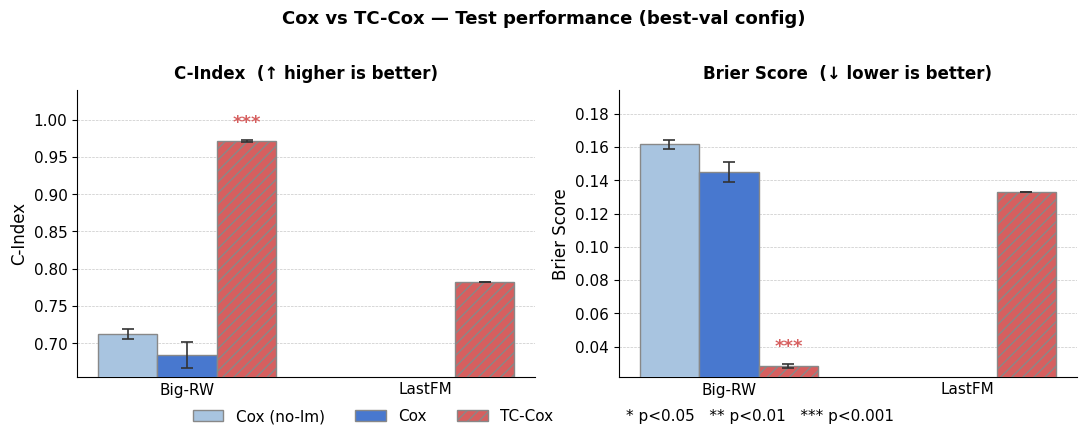

In [61]:
from scipy.stats import ttest_rel
import matplotlib.patches as mpatches

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

def summary_comparison_plot(df, save_path=None):
    """
    Conference-grade grouped bar chart: Cox(no-lm) / Cox(lm) / TC-Cox per dataset.
    Significance stars above TC-Cox bar from paired t-test vs Cox(landmark=True).
    Error bars = std / sqrt(n_seeds).
    """
    dataset_order  = ['nasa', 'big_rw', 'mimic', 'churn_lastfm_months']
    dataset_labels = {'nasa': 'NASA', 'big_rw': 'Big-RW', 'mimic': 'MIMIC', 'churn_lastfm_months': 'LastFM'}
    datasets = [d for d in dataset_order if d in df['dataset'].unique()]

    plt.rcParams.update({
        'font.family': 'sans-serif', 'font.size': 11,
        'axes.linewidth': 0.8, 'pdf.fonttype': 42,
    })

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    bar_w   = 0.25
    x       = np.arange(len(datasets))
    offsets = [-bar_w, 0, bar_w]
    clr   = {'Cox (no-lm)': '#A8C4E0', 'Cox': '#4878CF', 'TC-Cox': '#D65F5F'}
    hatch = {'Cox (no-lm)': '',         'Cox': '',         'TC-Cox': '///'}

    metrics = [
        ('val_ci', 'test_ci', 'C-Index',     True),
        ('val_bs', 'test_bs', 'Brier Score', False),
    ]

    for ax, (val_col, test_col, ylabel, higher_better) in zip(axes, metrics):
        nolm_means, nolm_errs = [], []
        lm_means,   lm_errs   = [], []
        tc_means,   tc_errs   = [], []
        pvals = []

        for dataset in datasets:
            dset  = df[df['dataset'] == dataset]
            sa_no = dset[(dset['algorithm'] == 'SA') & (dset['landmark'] == False)]
            sa_lm = dset[(dset['algorithm'] == 'SA') & (dset['landmark'] == True)]
            tc    = dset[dset['algorithm'] == 'DeepLambdaSA']

            # Cox (no-lm)
            s = sa_no[test_col].dropna().values
            nolm_means.append(s.mean() if len(s) else np.nan)
            nolm_errs.append(s.std() / np.sqrt(len(s)) if len(s) > 1 else 0)

            # Cox (landmark)
            s = sa_lm[test_col].dropna().values
            lm_means.append(s.mean() if len(s) else np.nan)
            lm_errs.append(s.std() / np.sqrt(len(s)) if len(s) > 1 else 0)

            # TC-Cox: best config by mean val metric
            if len(tc) == 0:
                tc_means.append(np.nan); tc_errs.append(0); pvals.append(1.0); continue
            agg = tc.groupby(['lambda_', 'target_lr'])[val_col].mean()
            bl, bt = agg.idxmax() if higher_better else agg.idxmin()
            best = tc[(tc['lambda_'] == bl) & (tc['target_lr'] == bt)]
            bs = best[test_col].dropna().values
            tc_means.append(bs.mean() if len(bs) else np.nan)
            tc_errs.append(bs.std() / np.sqrt(len(bs)) if len(bs) > 1 else 0)

            # Paired t-test: TC-Cox vs Cox (landmark) on matched seeds
            lm_idx  = sa_lm.set_index('seed')
            tc_idx  = best.set_index('seed')
            common  = lm_idx.index.intersection(tc_idx.index)
            if len(common) >= 2:
                _, p = ttest_rel(tc_idx.loc[common, test_col].values,
                                 lm_idx.loc[common, test_col].values)
                pvals.append(p)
            else:
                pvals.append(1.0)

        ekw = dict(elinewidth=1.2, ecolor='#333333', capthick=1.2)
        ax.bar(x + offsets[0], nolm_means, bar_w, yerr=nolm_errs, capsize=4,
               color=clr['Cox (no-lm)'], hatch=hatch['Cox (no-lm)'],
               edgecolor='#888', error_kw=ekw, zorder=3)
        ax.bar(x + offsets[1], lm_means,   bar_w, yerr=lm_errs,   capsize=4,
               color=clr['Cox'],           hatch=hatch['Cox'],
               edgecolor='#888', error_kw=ekw, zorder=3)
        ax.bar(x + offsets[2], tc_means,   bar_w, yerr=tc_errs,   capsize=4,
               color=clr['TC-Cox'],        hatch=hatch['TC-Cox'],
               edgecolor='#888', error_kw=ekw, zorder=3)

        # y limits with headroom for stars
        all_pairs = list(zip(nolm_means + lm_means + tc_means, nolm_errs + lm_errs + tc_errs))
        valid = [(v, e) for v, e in all_pairs if not np.isnan(v)]
        if valid:
            lo = max(0, min(v - e for v, e in valid))
            hi = max(v + e for v, e in valid)
            rng = hi - lo
            ymax = hi + rng * 0.22
            ax.set_ylim(lo - rng * 0.04, ymax)
        else:
            ymax, lo = 1.0, 0.0

        # Significance stars above TC-Cox bar
        for i, (tc_m, tc_e, p) in enumerate(zip(tc_means, tc_errs, pvals)):
            stars = sig_stars(p)
            if stars and not np.isnan(tc_m):
                ax.text(x[i] + offsets[2], tc_m + tc_e + (ymax - lo) * 0.03,
                        stars, ha='center', va='bottom', fontsize=13,
                        color=clr['TC-Cox'], fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels([dataset_labels.get(d, d) for d in datasets], fontsize=11)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, zorder=0)
        ax.set_axisbelow(True)
        ax.tick_params(axis='x', length=0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        arrow = '↑ higher is better' if higher_better else '↓ lower is better'
        ax.set_title(f'{ylabel}  ({arrow})', fontsize=12, fontweight='bold', pad=8)

    handles = [
        mpatches.Patch(facecolor=clr['Cox (no-lm)'], label='Cox (no-lm)', edgecolor='#888'),
        mpatches.Patch(facecolor=clr['Cox'],          label='Cox',          edgecolor='#888'),
        mpatches.Patch(facecolor=clr['TC-Cox'],       label='TC-Cox', hatch='///', edgecolor='#888'),
        plt.Line2D([0], [0], color='none', label='* p<0.05   ** p<0.01   *** p<0.001'),
    ]
    fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False,
               fontsize=11, bbox_to_anchor=(0.5, -0.06))
    fig.suptitle('Cox vs TC-Cox — Test performance (best-val config)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"Saved → {save_path}")
    plt.show()

summary_comparison_plot(df, save_path='../summary_COX.pdf')
